In [40]:
# Dependencies (run once in a fresh environment)
# ------------------------------------------------------------
# This notebook implements the complete Meeting Health Dashboard pipeline:
# - Whisper audio transcription
# - transformer emotion/sentiment analysis
# - Sentence-BERT meeting-health classification from embeddings (no rule-based health scoring)
# - BERTopic topic extraction
# - GPT/OpenAI structured meeting summaries
# - LangChain + FAISS RAG Q&A over transcripts
# - Streamlit/dashboard-ready CSV exports
#
# If you are running this notebook locally, install the required packages:
#   pip install -U git+https://github.com/openai/whisper.git \
#       pandas numpy matplotlib seaborn librosa soundfile requests scikit-learn \
#       transformers accelerate torch sentence-transformers bertopic umap-learn hdbscan \
#       openai langchain langchain-openai langchain-community langchain-text-splitters \
#       faiss-cpu streamlit
#
# Set your OpenAI key before running the GPT/RAG cells:
#   export OPENAI_API_KEY="your_key_here"


In [41]:
# (Optional) scikit-learn is included above; keep this cell as a no-op for portability.


In [42]:
import os
import glob
import json
import re
from pathlib import Path
from typing import Any, Dict, List

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

import librosa
import soundfile as sf
import whisper
from transformers import pipeline
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from openai import OpenAI

import streamlit as st


In [43]:
from pathlib import Path
import requests
import glob

# Default is optimized for an interactive dashboard run.
# Set FULL_MEETING_RUN=1 before running the notebook to process complete audio files.
FULL_MEETING_RUN = os.getenv("FULL_MEETING_RUN", "0") == "1"
MAX_AUDIO_SECONDS = int(os.getenv("MAX_AUDIO_SECONDS", "90"))
MAX_MEETINGS = int(os.getenv("MAX_MEETINGS", "3"))

audio_dir = Path("meeting_audio")
audio_dir.mkdir(parents=True, exist_ok=True)
processing_audio_dir = Path("meeting_audio_clips")
processing_audio_dir.mkdir(parents=True, exist_ok=True)

audio_urls = [
    "https://groups.inf.ed.ac.uk/ami/ICSIsignals/NXT/Bdb001.interaction.wav",
    "https://groups.inf.ed.ac.uk/ami/ICSIsignals/NXT/Bed002.interaction.wav",
    "https://groups.inf.ed.ac.uk/ami/ICSIsignals/NXT/Bed003.interaction.wav",
]

def download_file(url: str, dest: Path, chunk_size: int = 1 << 20):
    dest.parent.mkdir(parents=True, exist_ok=True)
    with requests.get(url, stream=True, timeout=60) as r:
        r.raise_for_status()
        with open(dest, "wb") as f:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)

for url in audio_urls[:MAX_MEETINGS]:
    fname = audio_dir / url.split("/")[-1]
    if not fname.exists():
        print("Downloading", fname.name)
        download_file(url, fname)
    else:
        print("Already have", fname.name)

source_wav_files = sorted(audio_dir.glob("*.wav"))[:MAX_MEETINGS]

if FULL_MEETING_RUN:
    wav_files = [str(p) for p in source_wav_files]
    print(f"Processing full audio for {len(wav_files)} meetings.")
else:
    clipped_files = []
    for source_path in source_wav_files:
        clip_path = processing_audio_dir / f"{source_path.stem}_{MAX_AUDIO_SECONDS}s.wav"
        if not clip_path.exists():
            print(f"Creating {MAX_AUDIO_SECONDS}s dashboard clip for {source_path.name}")
            audio, sr = librosa.load(source_path, sr=16000, mono=True, duration=MAX_AUDIO_SECONDS)
            sf.write(clip_path, audio, sr)
        else:
            print("Already have clip", clip_path.name)
        clipped_files.append(str(clip_path))
    wav_files = clipped_files
    print(f"Processing {len(wav_files)} short audio clips. Set FULL_MEETING_RUN=1 for complete files.")

wav_files


Already have Bdb001.interaction.wav
Already have Bed002.interaction.wav
Already have Bed003.interaction.wav
Already have clip Bdb001.interaction_90s.wav
Already have clip Bed002.interaction_90s.wav
Already have clip Bed003.interaction_90s.wav
Processing 3 short audio clips. Set FULL_MEETING_RUN=1 for complete files.


['meeting_audio_clips/Bdb001.interaction_90s.wav',
 'meeting_audio_clips/Bed002.interaction_90s.wav',
 'meeting_audio_clips/Bed003.interaction_90s.wav']

In [44]:
# choose among: "tiny", "base", "small", "medium", "large"
whisper_model_name = os.getenv("WHISPER_MODEL", "tiny")
model = whisper.load_model(whisper_model_name)
print(f"Loaded Whisper model: {whisper_model_name}")

def transcribe_audio(path: str) -> str:
    print(f"Transcribing: {os.path.basename(path)}")
    result = model.transcribe(path)
    return result["text"]

meeting_ids = []
transcripts = []
durations = []

for wav in wav_files:
    meeting_id = os.path.splitext(os.path.basename(wav))[0]
    text = transcribe_audio(wav)

    # audio duration in seconds
    dur = librosa.get_duration(path=wav)

    meeting_ids.append(meeting_id)
    transcripts.append(text)
    durations.append(dur)

df = pd.DataFrame({
    "meeting_id": meeting_ids,
    "transcript": transcripts,
    "duration_sec": durations
})
df.head()


Loaded Whisper model: tiny
Transcribing: Bdb001.interaction_90s.wav
Transcribing: Bed002.interaction_90s.wav
Transcribing: Bed003.interaction_90s.wav


,meeting_id,transcript,duration_sec
0,Bdb001.interaction_90s,"Yeah, we had a long discussion about how much...",90.0
1,Bed002.interaction_90s,"Yes. Okay, we're on. So just make sure that t...",90.0
2,Bed003.interaction_90s,you this is a good go to the can to my unders...,90.0


In [45]:
df["word_count"] = df["transcript"].str.split().str.len()
df["chars"] = df["transcript"].str.len()

# Questions as a rough engagement proxy
df["question_marks"] = df["transcript"].str.count(r"\?")
df["questions_per_100_words"] = df["question_marks"] / (df["word_count"] / 100).replace(0, 1)

# Duration in minutes
df["duration_min"] = df["duration_sec"] / 60.0

df[["meeting_id", "duration_min", "word_count", "questions_per_100_words"]]


,meeting_id,duration_min,word_count,questions_per_100_words
0,Bdb001.interaction_90s,1.5,211,0.473934
1,Bed002.interaction_90s,1.5,211,0.473934
2,Bed003.interaction_90s,1.5,32,0.000000


In [46]:
# Emotion / sentiment classifier
emotion_classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None
)


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [47]:
# ----------------- LABEL GROUPS (robust to model label set) -----------------
# We derive the model's labels once and map them into positive/negative/neutral.
# This removes the earlier hard-coded "happiness" label (which this model typically doesn't output).

def _pipeline_labels_lower() -> set:
    try:
        sample = emotion_classifier("test", truncation=True, max_length=32)[0]
        return {d["label"].lower() for d in sample}
    except Exception:
        return set()

MODEL_LABELS = _pipeline_labels_lower()

POS_CANDIDATES = {"joy", "surprise", "love", "optimism"}
NEG_CANDIDATES = {"anger", "disgust", "fear", "sadness"}
NEU_CANDIDATES = {"neutral"}

POS_LABELS = POS_CANDIDATES & MODEL_LABELS
NEG_LABELS = NEG_CANDIDATES & MODEL_LABELS
NEU_LABELS = NEU_CANDIDATES & MODEL_LABELS

# Sensible fallback if we couldn't detect labels for any reason
if not POS_LABELS and not NEG_LABELS and not NEU_LABELS:
    POS_LABELS = {"joy"}
    NEG_LABELS = {"anger", "disgust", "fear", "sadness"}
    NEU_LABELS = {"neutral"}

print("Detected labels:", sorted(MODEL_LABELS) if MODEL_LABELS else "(unknown)")
print("Using POS_LABELS:", POS_LABELS)
print("Using NEG_LABELS:", NEG_LABELS)
print("Using NEU_LABELS:", NEU_LABELS)


Detected labels: ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']
Using POS_LABELS: {'surprise', 'joy'}
Using NEG_LABELS: {'fear', 'anger', 'disgust', 'sadness'}
Using NEU_LABELS: {'neutral'}


In [48]:
def normalize_classifier_scores(raw):
    """Normalize transformers pipeline output across package versions."""
    if isinstance(raw, dict):
        return [raw]
    if isinstance(raw, list) and raw and isinstance(raw[0], dict):
        return raw
    if isinstance(raw, list) and raw and isinstance(raw[0], list):
        return raw[0]
    return []


def chunk_text(text, chunk_size_words=250):
    """Split text into chunks of <chunk_size_words> words."""
    words = text.split()
    for i in range(0, len(words), chunk_size_words):
        yield " ".join(words[i:i + chunk_size_words])

def get_emotion_scores(text: str):
    """
    Run the emotion model on word-chunks and average the scores.
    This avoids the 512 token limit issue.
    """
    text = text.strip()
    if not text:
        return {}

    chunks = list(chunk_text(text, chunk_size_words=250))

    all_scores = None
    for ch in chunks:
        # truncation=True and max_length=512 guarantee we stay in bounds
        res = normalize_classifier_scores(emotion_classifier(
            ch,
            truncation=True,
            max_length=512
        ))  # list of {label, score}

        if all_scores is None:
            all_scores = {item["label"]: float(item["score"]) for item in res}
        else:
            for item in res:
                all_scores[item["label"]] += float(item["score"])

    # average across chunks
    for k in all_scores:
        all_scores[k] /= len(chunks)

    return all_scores

emotion_dicts = []
for row in df.itertuples():
    print("Emotions for:", row.meeting_id)
    scores = get_emotion_scores(row.transcript)
    emotion_dicts.append(scores)

emotion_df = pd.DataFrame(emotion_dicts)
emotion_df["meeting_id"] = df["meeting_id"]
emotion_df.head()


Emotions for: Bdb001.interaction_90s
Emotions for: Bed002.interaction_90s
Emotions for: Bed003.interaction_90s


,neutral,disgust,surprise,anger,fear,sadness,joy,meeting_id
0,0.727096,0.200246,0.027160,0.017182,0.016476,0.008093,0.003746,Bdb001.interaction_90s
1,0.954218,0.016958,0.010972,0.010327,0.002812,0.002769,0.001944,Bed002.interaction_90s
2,0.748999,0.014772,0.013113,0.100080,0.049684,0.009904,0.063447,Bed003.interaction_90s


In [49]:
full_df = df.merge(emotion_df, on="meeting_id", how="left")

# Map model labels -> available columns (case-insensitive)
label_to_col = {c.lower(): c for c in full_df.columns if c not in {"meeting_id"}}

neg_cols = [label_to_col[l] for l in NEG_LABELS if l in label_to_col]
pos_cols = [label_to_col[l] for l in POS_LABELS if l in label_to_col]
neu_cols = [label_to_col[l] for l in NEU_LABELS if l in label_to_col]

full_df["neg_score"] = full_df[neg_cols].sum(axis=1) if neg_cols else 0.0
full_df["pos_score"] = full_df[pos_cols].sum(axis=1) if pos_cols else 0.0
full_df["neu_score"] = full_df[neu_cols].sum(axis=1) if neu_cols else 0.0

# Transcript-level tone metric (valence)
full_df["transcript_health_valence"] = full_df["pos_score"] - full_df["neg_score"]

# Optional: scaled score for UI (0..100)
full_df["transcript_health_score"] = ((full_df["transcript_health_valence"] + 1) / 2 * 100).clip(0, 100)

full_df[[
    "meeting_id", "duration_min", "word_count", "questions_per_100_words",
    "pos_score", "neg_score", "neu_score",
    "transcript_health_valence", "transcript_health_score"
]]


,meeting_id,duration_min,word_count,questions_per_100_words,pos_score,neg_score,neu_score,transcript_health_valence,transcript_health_score
0,Bdb001.interaction_90s,1.5,211,0.473934,0.030907,0.241997,0.727096,-0.211091,39.445475
1,Bed002.interaction_90s,1.5,211,0.473934,0.012916,0.032866,0.954218,-0.019950,49.002497
2,Bed003.interaction_90s,1.5,32,0.000000,0.076560,0.174441,0.748999,-0.097881,45.105938


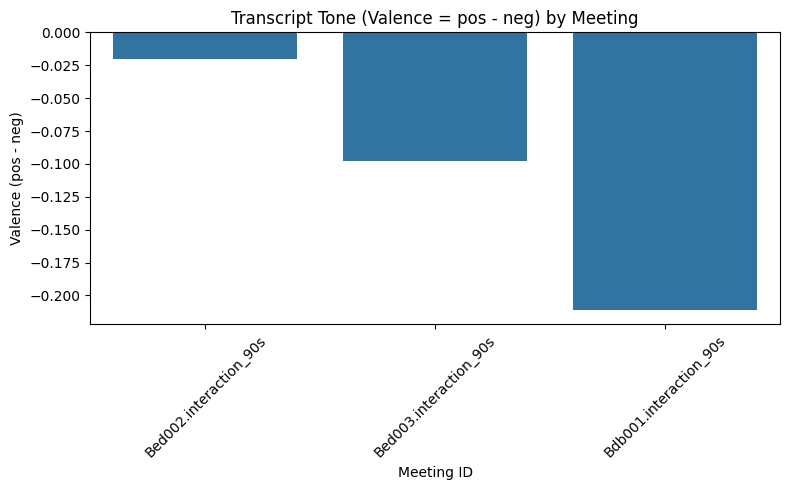

In [50]:
summary = full_df[[
    "meeting_id", "duration_min", "word_count",
    "questions_per_100_words", "transcript_health_valence"
]].sort_values("transcript_health_valence", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=summary, x="meeting_id", y="transcript_health_valence")
plt.title("Transcript Tone (Valence = pos - neg) by Meeting")
plt.xlabel("Meeting ID")
plt.ylabel("Valence (pos - neg)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


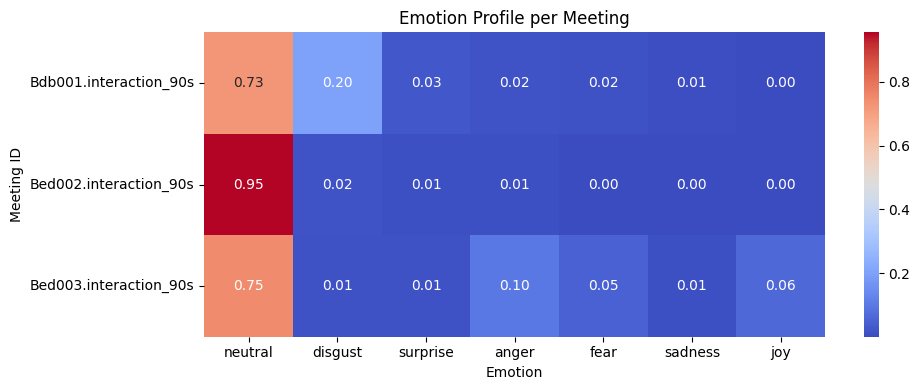

In [51]:
emotion_cols = [c for c in full_df.columns
                if c not in [
                    "meeting_id", "transcript", "duration_sec", "duration_min",
                    "word_count", "chars", "question_marks", "questions_per_100_words",
                    "neg_score", "pos_score", "neu_score", "transcript_health_valence", "transcript_health_score"
                ]]

heatmap_df = full_df.set_index("meeting_id")[emotion_cols]

plt.figure(figsize=(10, 4))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Emotion Profile per Meeting")
plt.ylabel("Meeting ID")
plt.xlabel("Emotion")
plt.tight_layout()
plt.show()


In [52]:
# Best (healthiest tone) and worst (most negative tone) meetings (TRANSCRIPT VALENCE)
best = full_df.sort_values("transcript_health_valence", ascending=False).head(1)
worst = full_df.sort_values("transcript_health_valence").head(1)

for _, row in pd.concat([best, worst]).iterrows():
    print("=" * 80)
    print(f"Meeting: {row['meeting_id']}")
    print(f"Transcript valence (pos - neg): {row['transcript_health_valence']:.3f}")
    print(f"Transcript health score (0..100): {row['transcript_health_score']:.1f}")
    print(f"Duration (min): {row['duration_min']:.1f}")
    print(f"Word count: {row['word_count']}")
    print(f"Questions per 100 words: {row['questions_per_100_words']:.2f}")


Meeting: Bed002.interaction_90s
Transcript valence (pos - neg): -0.020
Transcript health score (0..100): 49.0
Duration (min): 1.5
Word count: 211
Questions per 100 words: 0.47
Meeting: Bdb001.interaction_90s
Transcript valence (pos - neg): -0.211
Transcript health score (0..100): 39.4
Duration (min): 1.5
Word count: 211
Questions per 100 words: 0.47


In [53]:
# CHUNK-LEVEL SENTIMENT FLOW ANALYSIS

def split_into_word_chunks(text, chunk_size=40):
    """Split transcript into word-based chunks to approximate 'time steps'."""
    words = text.split()
    chunks = []
    for i in range(0, len(words), chunk_size):
        chunk_text = " ".join(words[i:i+chunk_size])
        if chunk_text.strip():
            chunks.append(chunk_text)
    return chunks


def compute_chunk_emotions(meeting_id, transcript, chunk_size=40):
    """
    For one meeting:
    - split transcript into chunks (approximate time)
    - run emotion classifier in BATCH (faster) with truncation safeguards
    - compute pos/neg/neu + valence
    Returns a DataFrame with one row per chunk.
    """
    chunks = split_into_word_chunks(transcript, chunk_size=chunk_size)
    if not chunks:
        return pd.DataFrame(columns=[
            "meeting_id","chunk_idx","chunk_text","pos_score","neg_score","neu_score","valence"
        ])

    # Batch inference (list in, list out)
    outputs = emotion_classifier(chunks, truncation=True, max_length=512)

    records = []
    for idx, raw in enumerate(outputs):
        # raw: list of {label, score}; normalize for transformers version differences
        raw_scores = normalize_classifier_scores(raw)
        label_scores = {d["label"].lower(): float(d["score"]) for d in raw_scores}

        pos_score = sum(label_scores.get(l, 0.0) for l in POS_LABELS)
        neg_score = sum(label_scores.get(l, 0.0) for l in NEG_LABELS)
        neu_score = sum(label_scores.get(l, 0.0) for l in NEU_LABELS)
        valence = pos_score - neg_score

        record = {
            "meeting_id": meeting_id,
            "chunk_idx": idx,
            "chunk_text": chunks[idx],
            "pos_score": pos_score,
            "neg_score": neg_score,
            "neu_score": neu_score,
            "valence": valence,
        }

        # also keep all raw emotion scores if you want them later
        for label, score in label_scores.items():
            record[f"emo_{label}"] = score

        records.append(record)

    return pd.DataFrame(records)


# Run chunk-level analysis for all meetings
chunk_level_dfs = []
for row in df.itertuples():
    print(f"Computing chunk-level emotions for meeting {row.meeting_id}...")
    chunk_df = compute_chunk_emotions(row.meeting_id, row.transcript, chunk_size=40)
    chunk_level_dfs.append(chunk_df)

chunk_level_df = pd.concat(chunk_level_dfs, ignore_index=True)
chunk_level_df.head()


Computing chunk-level emotions for meeting Bdb001.interaction_90s...
Computing chunk-level emotions for meeting Bed002.interaction_90s...
Computing chunk-level emotions for meeting Bed003.interaction_90s...


,meeting_id,chunk_idx,chunk_text,pos_score,neg_score,neu_score,valence,emo_neutral,emo_surprise,emo_sadness,emo_disgust,emo_anger,emo_joy,emo_fear
0,Bdb001.interaction_90s,0,"Yeah, we had a long discussion about how much ...",0.077572,0.037798,0.884629,0.039774,0.884629,0.071913,0.011901,0.011800,0.010069,0.005659,0.004029
1,Bdb001.interaction_90s,1,started it so I don't know if it doesn't like ...,0.240094,0.051976,0.707930,0.188118,0.707930,0.236331,0.008660,0.023534,0.015367,0.003763,0.004416
2,Bdb001.interaction_90s,2,"little indicator on the AF So if you yeah, if ...",0.028943,0.522528,0.448529,-0.493585,0.448529,0.022854,0.010584,0.466672,0.024135,0.006089,0.021137
3,Bdb001.interaction_90s,3,it In fact if you listen to just the channels ...,0.043533,0.108140,0.848327,-0.064607,0.848327,0.035014,0.013801,0.052978,0.020212,0.008520,0.021149
4,Bdb001.interaction_90s,4,an hour because I Really people coming and the...,0.726885,0.081568,0.191547,0.645317,0.191547,0.638888,0.023101,0.002893,0.022870,0.087997,0.032704


In [54]:
# SENTENCE-BERT MEETING HEALTH CLASSIFICATION + KEY MOMENTS
# ---------------------------------------------------------
# This replaces rule-based meeting-health scoring with embedding similarity.
# The meeting transcript is embedded with Sentence-BERT and classified against
# health/collaboration/tension profile descriptions.

sentence_model_name = "all-MiniLM-L6-v2"
sentence_model = SentenceTransformer(sentence_model_name)
print(f"Loaded Sentence-BERT model: {sentence_model_name}")

health_profiles = pd.DataFrame([
    {
        "health_label": "excellent",
        "profile_text": "A highly productive collaborative meeting with clear decisions, shared understanding, constructive discussion, low tension, and concrete next steps.",
        "meeting_health_score": 95,
        "collaboration_score": 95,
        "tension_score": 5,
    },
    {
        "health_label": "healthy",
        "profile_text": "A mostly positive meeting with useful participation, good alignment, some decisions, and manageable disagreement.",
        "meeting_health_score": 80,
        "collaboration_score": 82,
        "tension_score": 18,
    },
    {
        "health_label": "mixed",
        "profile_text": "A mixed meeting with partial alignment, uneven participation, unresolved questions, and occasional confusion or disagreement.",
        "meeting_health_score": 55,
        "collaboration_score": 55,
        "tension_score": 45,
    },
    {
        "health_label": "tense",
        "profile_text": "A tense meeting with noticeable disagreement, frustration, unclear ownership, unresolved blockers, and strained communication.",
        "meeting_health_score": 30,
        "collaboration_score": 30,
        "tension_score": 75,
    },
    {
        "health_label": "unproductive",
        "profile_text": "An unproductive meeting with low alignment, poor collaboration, repeated confusion, few decisions, and no clear action items.",
        "meeting_health_score": 15,
        "collaboration_score": 20,
        "tension_score": 60,
    },
])

profile_embeddings = sentence_model.encode(
    health_profiles["profile_text"].tolist(),
    normalize_embeddings=True,
    show_progress_bar=False,
)


def softmax(values, temperature=0.12):
    values = np.asarray(values, dtype=float) / temperature
    values = values - values.max()
    exp_values = np.exp(values)
    return exp_values / exp_values.sum()


def classify_meeting_health_with_sbert(transcript: str) -> Dict[str, Any]:
    """Classify meeting health from transcript embeddings using Sentence-BERT similarity."""
    meeting_embedding = sentence_model.encode(
        [transcript or ""],
        normalize_embeddings=True,
        show_progress_bar=False,
    )
    similarities = cosine_similarity(meeting_embedding, profile_embeddings)[0]
    weights = softmax(similarities)
    best_idx = int(np.argmax(similarities))

    weighted = {}
    for metric in ["meeting_health_score", "collaboration_score", "tension_score"]:
        weighted[metric] = float(np.average(health_profiles[metric], weights=weights))

    health_valence = (weighted["meeting_health_score"] / 50.0) - 1.0

    return {
        "predicted_health_label": health_profiles.loc[best_idx, "health_label"],
        "health_confidence": float(weights[best_idx]),
        "meeting_health_valence": float(np.clip(health_valence, -1, 1)),
        **weighted,
        "embedding_model": sentence_model_name,
    }


def add_sentiment_deltas(chunk_df: pd.DataFrame) -> pd.DataFrame:
    """Add signed and absolute valence deltas within each meeting."""
    if chunk_df.empty:
        out = chunk_df.copy()
        out["delta_valence"] = pd.Series(dtype="float")
        out["abs_delta_valence"] = pd.Series(dtype="float")
        return out

    out = chunk_df.sort_values(["meeting_id", "chunk_idx"]).copy()
    out["delta_valence"] = out.groupby("meeting_id")["valence"].diff()
    out["abs_delta_valence"] = out["delta_valence"].abs()
    return out


def detect_key_moments(chunk_df: pd.DataFrame, top_n: int = 5) -> pd.DataFrame:
    """Detect the largest chunk-to-chunk transformer sentiment shifts per meeting."""
    records = []
    if chunk_df.empty:
        return pd.DataFrame(columns=[
            "meeting_id", "chunk_idx", "chunk_text", "pos_score", "neg_score", "neu_score",
            "valence", "delta_valence", "abs_delta_valence", "shift_rank"
        ])

    for meeting_id, sub in chunk_df.groupby("meeting_id"):
        ranked = (
            sub.dropna(subset=["abs_delta_valence"])
               .sort_values("abs_delta_valence", ascending=False)
               .head(top_n)
               .copy()
        )
        ranked["shift_rank"] = range(1, len(ranked) + 1)
        records.append(ranked)

    if not records:
        return pd.DataFrame(columns=[
            "meeting_id", "chunk_idx", "chunk_text", "pos_score", "neg_score", "neu_score",
            "valence", "delta_valence", "abs_delta_valence", "shift_rank"
        ])
    return pd.concat(records, ignore_index=True)


# Add deltas to the chunk table for dashboard sentiment-flow visualizations.
chunk_level_df = add_sentiment_deltas(chunk_level_df)

# Classify every full transcript with Sentence-BERT profile similarity.
meeting_metrics = []
for row in df.itertuples():
    metrics = classify_meeting_health_with_sbert(row.transcript)
    metrics["meeting_id"] = row.meeting_id
    meeting_metrics.append(metrics)

meeting_metrics_df = pd.DataFrame(meeting_metrics)

# Add simple transcript metadata for dashboard context. These are descriptive metadata,
# not the meeting-health classifier.
meeting_metrics_df = meeting_metrics_df.merge(
    df[["meeting_id", "duration_min", "word_count", "questions_per_100_words"]],
    on="meeting_id",
    how="left"
)

key_moments_df = detect_key_moments(chunk_level_df, top_n=5)
key_moment_columns = [
    "meeting_id", "chunk_idx", "chunk_text", "pos_score", "neg_score", "neu_score",
    "valence", "delta_valence", "abs_delta_valence", "shift_rank"
]
for col in key_moment_columns:
    if col not in key_moments_df.columns:
        key_moments_df[col] = pd.Series(dtype="float" if "score" in col or "valence" in col else "object")
key_moments_df = key_moments_df[key_moment_columns]

meeting_metrics_df[[
    "meeting_id", "predicted_health_label", "health_confidence",
    "meeting_health_score", "collaboration_score", "tension_score", "meeting_health_valence"
]].head()


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loaded Sentence-BERT model: all-MiniLM-L6-v2


,meeting_id,predicted_health_label,health_confidence,meeting_health_score,collaboration_score,tension_score,meeting_health_valence
0,Bdb001.interaction_90s,mixed,0.275018,57.102613,58.272365,39.023511,0.142052
1,Bed002.interaction_90s,mixed,0.313221,52.493961,53.416923,44.901058,0.049879
2,Bed003.interaction_90s,tense,0.315171,55.600160,56.516074,42.341081,0.112003


In [55]:
# TOPIC MODELING + TOPIC-HEALTH CORRELATION
# -----------------------------------------
# Fast-safe local topic insights.
#
# NOTE: Full BERTopic clustering is intentionally disabled in this notebook because
# it can crash or hang local Jupyter kernels on small laptops. The dashboard still
# gets topic-health insights from TF-IDF keywords plus the existing meeting-health
# scores, which is stable and fast for local runs.

from sklearn.feature_extraction.text import TfidfVectorizer

corpus = df["transcript"].fillna("").tolist()
meeting_id_list = df["meeting_id"].tolist()
transcript_embeddings = sentence_model.encode(
    corpus,
    normalize_embeddings=True,
    show_progress_bar=False,
)


def fallback_topic_keywords(texts, top_n=8):
    """Fast keyword-based topic labels for local dashboard runs."""
    vectorizer = TfidfVectorizer(stop_words="english", max_features=500, min_df=1)
    matrix = vectorizer.fit_transform(texts)
    feature_names = np.array(vectorizer.get_feature_names_out())
    keywords = []
    for row_idx in range(matrix.shape[0]):
        row = matrix[row_idx].toarray().ravel()
        top_idx = row.argsort()[-top_n:][::-1]
        words = [feature_names[i] for i in top_idx if row[i] > 0]
        keywords.append(", ".join(words) if words else "meeting discussion")
    return keywords


topic_model = None
topics = list(range(len(corpus)))
keywords = fallback_topic_keywords(corpus)

topic_assignments_df = pd.DataFrame({
    "meeting_id": meeting_id_list,
    "topic_id": topics,
    "topic": [f"topic_{idx}" for idx in topics],
    "keywords": keywords,
})

topic_info = pd.DataFrame({
    "Topic": topics,
    "Count": [1 for _ in topics],
    "Name": [f"topic_{idx}_{kw.split(',')[0] if kw else 'meeting'}" for idx, kw in zip(topics, keywords)],
})

topic_sentiment_df = topic_assignments_df.merge(
    meeting_metrics_df[["meeting_id", "meeting_health_score", "meeting_health_valence"]],
    on="meeting_id",
    how="left"
)

topic_health = (
    topic_sentiment_df
    .groupby(["topic", "topic_id", "keywords"], as_index=False)
    .agg(
        avg_health_score=("meeting_health_score", "mean"),
        avg_meeting_health=("meeting_health_valence", "mean"),
        meeting_count=("meeting_id", "nunique"),
    )
    .sort_values("avg_health_score", ascending=False)
)

topic_health



,topic,topic_id,keywords,avg_health_score,avg_meeting_health,meeting_count
0,topic_0,0,"like, people, know, yesterday, yeah, breathe, ...",57.102613,0.142052,1
2,topic_2,2,"okay, control, f7, hit, understanding, did, th...",55.600160,0.112003,1
1,topic_1,1,"read, digits, just, strings, number, pause, li...",52.493961,0.049879,1


In [64]:
# GPT API STRUCTURED MEETING SUMMARIES
# ------------------------------------
# Uses the OpenAI API to generate structured summaries with action items,
# key decisions, and tension points from raw transcripts.

from dotenv import load_dotenv

load_dotenv()

openai_api_key = os.getenv("OPENAI_API_KEY")
gpt_summary_model = os.getenv("OPENAI_SUMMARY_MODEL", "gpt-4o-mini")

summary_schema_hint = {
    "summary": "2-4 sentence meeting summary",
    "action_items": [
        {"owner": "person or team if stated, otherwise unknown", "task": "specific action", "due_date": "date if stated, otherwise null"}
    ],
    "key_decisions": ["decision 1"],
    "tension_points": ["point of disagreement, blocker, confusion, or risk"],
}


def extract_json_object(text: str) -> Dict[str, Any]:
    """Parse a JSON object from an LLM response."""
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        match = re.search(r"\{.*\}", text, flags=re.DOTALL)
        if match:
            return json.loads(match.group(0))
        raise


def generate_meeting_summary(transcript: str, meeting_id: str) -> Dict[str, Any]:
    """Generate one structured GPT summary for a transcript."""
    """if not openai_api_key:
        return {
            "meeting_id": meeting_id,
            "summary": "OPENAI_API_KEY not set; summary generation skipped.",
            "action_items": [],
            "key_decisions": [],
            "tension_points": [],
            "model": gpt_summary_model,
        }"""

    client = OpenAI(api_key=openai_api_key)
    prompt = f"""
You are analyzing a meeting transcript for a Meeting Health Dashboard.
Return only valid JSON matching this schema:
{json.dumps(summary_schema_hint, indent=2)}

Meeting ID: {meeting_id}
Transcript:
{transcript[:12000]}
""".strip()

    response = client.chat.completions.create(
        model=gpt_summary_model,
        temperature=0.2,
        messages=[
            {"role": "system", "content": "You extract concise structured meeting intelligence from transcripts."},
            {"role": "user", "content": prompt},
        ],
    )
    parsed = extract_json_object(response.choices[0].message.content)
    parsed["meeting_id"] = meeting_id
    parsed["model"] = gpt_summary_model
    return parsed


meeting_summary_records = []
for row in df.itertuples():
    print(f"Generating structured GPT summary for {row.meeting_id}...")
    meeting_summary_records.append(generate_meeting_summary(row.transcript, row.meeting_id))

meeting_summaries_df = pd.DataFrame(meeting_summary_records)
meeting_summaries_df


Generating structured GPT summary for Bdb001.interaction_90s...
Generating structured GPT summary for Bed002.interaction_90s...
Generating structured GPT summary for Bed003.interaction_90s...


,summary,action_items,key_decisions,tension_points,meeting_id,model
0,The meeting focused on the ease of belief in i...,"[{'owner': 'unknown', 'task': 'Provide input o...",[],[Disagreement on how easy to make belief in in...,Bdb001.interaction_90s,gpt-4o-mini
1,The meeting focused on the proper procedure fo...,"[{'owner': 'unknown', 'task': 'Ensure wireless...",[Participants will read digit strings individu...,[Uncertainty about the cognitive load of readi...,Bed002.interaction_90s,gpt-4o-mini
2,The meeting involved a discussion about task c...,"[{'owner': 'unknown', 'task': 'Confirm complet...",[],[Unclear if all tasks were completed as expected],Bed003.interaction_90s,gpt-4o-mini


In [63]:
# LANGCHAIN + FAISS RAG Q&A OVER MEETING TRANSCRIPTS
# --------------------------------------------------
# Builds a FAISS vector store over transcript chunks and exposes a natural-language
# query function for semantic search across the full conversation history.

try:
    from langchain_text_splitters import RecursiveCharacterTextSplitter
except ImportError:
    from langchain.text_splitter import RecursiveCharacterTextSplitter

try:
    from langchain_core.documents import Document
except ImportError:
    from langchain.docstore.document import Document

try:
    from langchain_openai import OpenAIEmbeddings, ChatOpenAI
except ImportError:
    from langchain.embeddings import OpenAIEmbeddings
    from langchain.chat_models import ChatOpenAI

try:
    from langchain_community.vectorstores import FAISS
except ImportError:
    from langchain.vectorstores import FAISS

rag_model = os.getenv("OPENAI_RAG_MODEL", "gpt-4o-mini")
embedding_model_name = os.getenv("OPENAI_EMBEDDING_MODEL", "text-embedding-3-small")

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=900,
    chunk_overlap=150,
    separators=["\n\n", "\n", ". ", " ", ""],
)

documents = []
for row in df.itertuples():
    chunks = text_splitter.split_text(row.transcript or "")
    for chunk_idx, chunk in enumerate(chunks):
        documents.append(Document(
            page_content=chunk,
            metadata={"meeting_id": row.meeting_id, "chunk_idx": chunk_idx},
        ))

if openai_api_key:
    openai_embeddings = OpenAIEmbeddings(model=embedding_model_name, api_key=openai_api_key)
    faiss_vector_store = FAISS.from_documents(documents, openai_embeddings)
    faiss_vector_store.save_local("meeting_transcript_faiss_index")
    print(f"Built FAISS vector store with {len(documents)} transcript chunks.")
else:
    faiss_vector_store = None
    print("OPENAI_API_KEY not set; FAISS/OpenAI embedding index build skipped.")


def ask_meeting_rag(question: str, k: int = 5) -> Dict[str, Any]:
    """Ask a natural-language question over all meeting transcripts using LangChain + FAISS."""
    if faiss_vector_store is None:
        raise RuntimeError("Set OPENAI_API_KEY and rerun this cell to build the FAISS vector store.")

    retriever = faiss_vector_store.as_retriever(search_kwargs={"k": k})
    source_docs = retriever.invoke(question)
    context = "\n\n".join(
        f"Meeting {doc.metadata.get('meeting_id')} chunk {doc.metadata.get('chunk_idx')}:\n{doc.page_content}"
        for doc in source_docs
    )

    llm = ChatOpenAI(model=rag_model, temperature=0.1, api_key=openai_api_key)
    answer = llm.invoke([
        ("system", "Answer questions using only the provided meeting transcript context. Cite meeting IDs and chunk numbers."),
        ("user", f"Context:\n{context}\n\nQuestion: {question}"),
    ])

    return {
        "question": question,
        "answer": answer.content,
        "sources": [doc.metadata for doc in source_docs],
    }

# Example after setting OPENAI_API_KEY:
# ask_meeting_rag("What decisions were made and what action items came out of the tense parts?")


Built FAISS vector store with 5 transcript chunks.


In [58]:
# ----------------- EXPORT DASHBOARD ARTIFACTS -----------------
# The dashboard loads these files automatically after this cell runs.

from pathlib import Path

output_dirs = [
    Path.cwd(),
    Path("/Users/saiteja/Desktop/meeting_health_dashboard/data"),
]
for output_dir in output_dirs:
    output_dir.mkdir(parents=True, exist_ok=True)

required_outputs = {
    "meeting_metrics_df.csv": (meeting_metrics_df, {
        "meeting_id", "meeting_health_valence", "meeting_health_score",
        "collaboration_score", "tension_score", "predicted_health_label"
    }),
    "chunk_level_df.csv": (chunk_level_df, {
        "meeting_id", "chunk_idx", "chunk_text", "valence", "delta_valence"
    }),
    "key_moments_df.csv": (key_moments_df, {
        "meeting_id", "chunk_idx", "delta_valence", "chunk_text", "shift_rank"
    }),
    "topic_health.csv": (topic_health, {
        "topic", "keywords", "avg_health_score", "avg_meeting_health"
    }),
    "meeting_summaries_df.csv": (meeting_summaries_df, {
        "meeting_id", "summary", "action_items", "key_decisions", "tension_points"
    }),
}

for filename, (table, required_columns) in required_outputs.items():
    missing = required_columns - set(table.columns)
    if missing:
        raise ValueError(f"{filename} is missing required columns: {sorted(missing)}")
    for output_dir in output_dirs:
        table.to_csv(output_dir / filename, index=False)

for output_dir in output_dirs:
    with open(output_dir / "meeting_summaries.json", "w") as f:
        json.dump(meeting_summary_records, f, indent=2)
    topic_info.to_csv(output_dir / "bertopic_topic_info.csv", index=False)
    topic_assignments_df.to_csv(output_dir / "bertopic_meeting_topics.csv", index=False)

if faiss_vector_store is not None:
    faiss_vector_store.save_local(str(Path("/Users/saiteja/Desktop/meeting_health_dashboard/data/meeting_transcript_faiss_index")))

print("Saved dashboard-ready artifacts to:")
for output_dir in output_dirs:
    print(f" - {output_dir}")

print("\nFiles saved:")
for filename in required_outputs:
    print(f" - {filename}")
print(" - meeting_summaries.json")
print(" - bertopic_topic_info.csv")
print(" - bertopic_meeting_topics.csv")
if faiss_vector_store is not None:
    print(" - meeting_transcript_faiss_index/")

print("\nRefresh the Streamlit dashboard after this cell finishes; it will load these files automatically.")



Saved dashboard-ready artifacts to:
 - /Users/saiteja/Desktop/meeting_health_dashboard_local/notebooks
 - /Users/saiteja/Desktop/meeting_health_dashboard/data

Files saved:
 - meeting_metrics_df.csv
 - chunk_level_df.csv
 - key_moments_df.csv
 - topic_health.csv
 - meeting_summaries_df.csv
 - meeting_summaries.json
 - bertopic_topic_info.csv
 - bertopic_meeting_topics.csv
 - meeting_transcript_faiss_index/

Refresh the Streamlit dashboard after this cell finishes; it will load these files automatically.
